In [218]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [219]:
import os
import pickle
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from pathlib import Path

from openquake.hazardlib.imt import PGA, SA, RSD595, AvgSA, IMT

from pickagm.distributions import ensemble_ecdfs

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    create_gmm_map,
    create_corr_model_map,
    calculate_site_gcim_distributions_for_all_sites,
    get_record_ensembles_for_site_and_poe,
    get_record_ensembles_for_sites,
    get_record_ensembles_for_single_site,
    get_gcim_distributions_for_single_site_and_poe,
    get_record_ensembles_for_single_distribution,
    get_imtl_from_disaggstats,
    get_imtl_from_disaggstats,
    get_gcim_distributions_for_single_site
)
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
from phd_project.plotting import custom_log_formatter

cfg = load_config()

In [220]:
# Load the disaggregation data
fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_06 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_06 = pickle.load(f)

# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0, low_memory=False)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)

# load the preprocessed gm database
gm_database = pd.read_csv(cfg["proc_data"]["gm_database"], sep=",", low_memory=False, header=[0, 1])

In [221]:
# create the average depth map for each TRT #TODO:: if this needs to be more specific
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# the map of what sim trts are allowed to match with what record trts
OK_TRT_MATCHES = {
    "Craton": ["Shallow Default"],
    "Non-Subduction Deep": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Shallow Default": ["Shallow Default"],
    "Subduction Inslab": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Subduction Interface": ["Subduction Interface"],
    "Volcanic": ["Shallow Default"],
}

occurence = True    # the record selection should be performed based on occurence

# AvgSA([0, 3])

In [222]:
# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 3         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,3])                      
nonSA_imts: list[IMT] = [AvgSA([0,3]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.30
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = 0                                # assumed rake for RSD595 calculation

In [223]:
# filter the gm_database so that only the selection and conditioning ims are present
gm_db_AvgSA_03 = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db_AvgSA_03["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db_AvgSA_03 = pd.concat([gm_db_AvgSA_03.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_03_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to3_median_branch.xml"
AvgSA_03_gmm_map = create_gmm_map(AvgSA_03_lt_fp)

# get the correlation model map
AvgSA_03_corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

In [235]:
# set up the selection context:
selection_ctx_AvgSA_03 = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": AvgSA_03_gmm_map ,
    "corr_map": AvgSA_03_corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": None, #(0.25, 4) ,
    "usable_T": t_upper ,
    "max_n_recs": 3 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

In [225]:
# seismicity = "high"
# region = 1
# site = 30
# rng_seed = 2

# site_gcim_dists = get_gcim_distributions_for_single_site(
#     site, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, selection_ctx_AvgSA_03)

# record_selection_results_AvgSA03 = get_record_ensembles_for_single_site(
#     site, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, site_gcim_dists, gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2)

In [226]:
# fp = Path(r"C:\Users\clemettn\Documents\phd\data_processed\06_gm_selection")
# with open(fp / f"site{site}_gcim_data_rake{assumed_rake}_sf_limit.pickle", "wb") as file:
#     pickle.dump(site_gcim_dists, file)

# with open(fp / f"site{site}_record_selections_rake{assumed_rake}_sf_limit.pickle", "wb") as file:
#     pickle.dump(record_selection_results_AvgSA03, file)

In [227]:
# records = record_selection_results_AvgSA03[0.0001]
# es = records["all_ensembles"]
# e = es[0]
# print(e.keys())
# for ei in es:
#     print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

In [228]:
# ensemble_data = records["best_ensemble"]
# ecdfs = ensemble_ecdfs(ensemble_data["recs"]["ims_scaled"])
# ensemble_data["ecdfs"] = ecdfs
# print(ensemble_data.keys())
# print(ecdfs.keys())

In [229]:
# im = "RSD595"
# poe1 = 0.000404
# poe2 = 0.0001
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

# # Figure 1 -> RSD595 KS-Test poe1
# records1 = record_selection_results_AvgSA03[poe1]
# if records1["ensemble_found"]:
#     ensemble1 = records1["best_ensemble"]
#     ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])
# else:
#     rscores = np.array([r["R-score"] for r in records1["all_ensembles"]])
#     idx = np.where(rscores == min(rscores))[0][0]
#     ensemble1 = records1["all_ensembles"][idx]
#     print(f"KS-Test failed for poe {poe1}. Showing ensemble with R = {ensemble1["R-score"]:.4f} and failed IMs {ensemble1["ks_failed_ims"]}")
#     ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])

# # target cdf and ks bounds
# ks_bounds = records1["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs1[im]

# ax1.plot(xs, lower, color="0.8", ls="--")
# ax1.plot(xs, cdf, color="0.8", ls="-")
# ax1.plot(xs, upper, color="0.8", ls="--")
# ax1.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# # ax1.grid(True, which="both", ls="-.", color="0.8")
# # ax1.minorticks_on()

# # Figure 2 -> RSD595 KS-Test poe2
# records2 = record_selection_results_AvgSA03[poe2]
# if records2["ensemble_found"]:
#     ensemble2 = records2["best_ensemble"]
#     ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])
# else:
#     rscores = np.array([r["R-score"] for r in records2["all_ensembles"]])
#     idx = np.where(rscores == min(rscores))[0][0]
#     ensemble2 = records2["all_ensembles"][idx]
#     print(f"KS-Test failed for poe {poe2}. Showing ensemble with R = {ensemble2["R-score"]:.4f} and failed IMs {ensemble2["ks_failed_ims"]}")
#     ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])

# # target cdf and ks bounds
# ks_bounds = records["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs2[im]

# ax2.plot(xs, lower, color="0.8", ls="--")
# ax2.plot(xs, cdf, color="0.8", ls="-")
# ax2.plot(xs, upper, color="0.8", ls="--")
# ax2.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# ax2.set_xlim(0, 80)
# ax2.set_ylim(0, 1.0)
# # ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
# ax2.set_ylabel(r"P[IM <= im]")
# # ax2.grid(True, which="both", ls="-.", color="0.8")
# # ax2.minorticks_on()
# fig.tight_layout()


In [230]:

# disagg_dist = disagg_data_AvgSA_03[(seismicity, region)][site]["AvgSA"][poe]

# iml = get_imtl_from_disaggstats(disagg_stats_AvgSA_03, site, seismicity, region, "AvgSA", poe)

# site_params = selection_ctx_AvgSA_03["sites"].loc[site,:].to_dict()

# gcim_out = get_gcim_distributions_for_single_site_and_poe(
#     site, poe, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, selection_ctx_AvgSA_03)

# records = get_record_ensembles_for_single_distribution(
#     disagg_dist, iml, selection_ctx_AvgSA_03, gm_db_AvgSA_03, 
#     site_params, gcim_out["cdfs"], rng_seed)

# records = get_record_ensembles_for_site_and_poe(
#     30, 0.002103, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, gcim_AvgSA_03, 
#     gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2)

print(f"Success: {records["ensemble_found"]}")

Success: False


In [231]:
# es = records["all_ensembles"]
# e = es[0]
# print(e.keys())
# for ei in es:
#     print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

## GCIM Target Distributions

In [236]:
LOAD_GCIM_IF_EXISTS = True
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_03_rake{int(assumed_rake)}.pickle"

if LOAD_GCIM_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if gcim_dist_fp.is_file():
        with open(gcim_dist_fp, "rb") as file:
            gcim_AvgSA_03 = pickle.load(file)
        print("Existing GCIM distribution data loaded...")
    else:
        no_file = True
        print("No existing GCIM distribution data found...")

if (not LOAD_GCIM_IF_EXISTS) or no_file:
    # calculate the gcims and save them
    gcim_AvgSA_03 = calculate_site_gcim_distributions_for_all_sites(
        disagg_data_AvgSA_03, disagg_stats_AvgSA_03, conditioning_imt, 
        selection_imts, sites, AvgSA_03_gmm_map, AvgSA_03_corr_map, 
        average_depths, assumed_rake, occurence, percentiles)

    with open(gcim_dist_fp, "wb") as file:
        pickle.dump(gcim_AvgSA_03, file)

Existing GCIM distribution data loaded...


## Selection

In [237]:
LOAD_RS_IF_EXISTS = False
only_sites = [30, 31, 37, 41, 3, 9]
AvgSA_03_gm_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_intermdiate_selection_results_rake{int(assumed_rake)}.pickle"

if LOAD_RS_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if AvgSA_03_gm_fp.is_file():
        with open(AvgSA_03_gm_fp, "rb") as file:
            record_selection_results_AvgSA03 = pickle.load(file)
        print("Existing record selection data loaded...")
    else:
        no_file = True
        print("No existing record selection data found...")
        
if (not LOAD_RS_IF_EXISTS) or no_file:
    # do the record selection for all sites and save the results
    record_selection_results_AvgSA03 = get_record_ensembles_for_sites(
        disagg_data_AvgSA_03, disagg_stats_AvgSA_03, gcim_AvgSA_03, 
        gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2, only_sites    
        )

    # Save the results
    with open(AvgSA_03_gm_fp, "wb") as file:
        pickle.dump(record_selection_results_AvgSA03, file)

Selecting Record Ensembles...
  Region 0 - high seismicity
    site id: 30
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 31
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 1 - high seismicity
    site id: 37
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 2 - high seismicity
    site id: 41
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 3 - high seismicity
  Region 4 - high seismicity
  Region 5 - high seismicity
  Region 0 - lowmod seismicity
    site id: 3
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 1 - lowmod seismicity
    site id: 9
     

In [238]:
# Check if all the sites and poes found a set of records successfully
no_ensemble_found_AvgSA03 = []
for (s, r) in record_selection_results_AvgSA03.keys():
    for site_id in record_selection_results_AvgSA03[(s,r)].keys():
        for poe, rsr in record_selection_results_AvgSA03[(s,r)][site_id].items():
            if not rsr["ensemble_found"]:
                no_ensemble_found_AvgSA03.append(((s,r), site_id, poe))

print(f"No records found for {len(no_ensemble_found_AvgSA03)} combinations of site and poe")
for ii in no_ensemble_found_AvgSA03:
    print(ii)

No records found for 0 combinations of site and poe


In [11]:
# get the best ensembles (the final record selection for each site)
# calculate the ecdfs, trt stats, and plot images.
# save everything in the results/folder

# get a list of all the esm and ngasub records that need to be downloaded


# AvgSA([0, 6])

In [212]:
# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 6         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,6])                      
nonSA_imts: list[IMT] = [AvgSA([0,6]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.8
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = 0                                # assumed rake for RSD595 calculation

In [213]:
# filter the gm_database so that only the selection and conditioning ims are present
gm_db_AvgSA_06 = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db_AvgSA_06["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db_AvgSA_06 = pd.concat([gm_db_AvgSA_06.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_06_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to6_median_branch.xml"
AvgSA_06_gmm_map = create_gmm_map(AvgSA_06_lt_fp)

# get the correlation model map
AvgSA_06_corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

In [214]:
# set up the selection context:
selection_ctx_AvgSA_06 = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": AvgSA_06_gmm_map ,
    "corr_map": AvgSA_06_corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": None,#(0.25, 4) ,
    "usable_T": t_upper ,
    "max_n_recs": 3 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

In [ ]:
site = 31
rng_seed = 3

site_gcim_dists_06 = get_gcim_distributions_for_single_site(
    site, disagg_data_AvgSA_06, disagg_stats_AvgSA_06, selection_ctx_AvgSA_06)

record_selection_results_AvgSA06 = get_record_ensembles_for_single_site(
    site, disagg_data_AvgSA_06, disagg_stats_AvgSA_06, site_gcim_dists_06, gm_db_AvgSA_06, selection_ctx_AvgSA_06, rng_seed)

Calculating GCIM distributions for Site 31
Calculating Record Ensembles for Site 31
poe:  0.004988
poe:  0.002103
poe:  0.001
poe:  0.000404
poe:  0.000201
poe:  0.0001


In [216]:
records = record_selection_results_AvgSA06[0.0001]
es = records["all_ensembles"]
e = es[0]
print(e.keys())
for ei in es:
    print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

dict_keys(['sims', 'mu_cond', 'sig_cond', 'ctxs', 'eps', 'recs', 'ks_passed', 'ks_results', 'ks_failed_ims', 'R-score'])
False, 0.5606, ['RSD595', 'SA(0.597)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)']
False, 0.6321, ['RSD595', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.251)', 'SA(1.418)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)', 'SA(6.0)']
False, 0.5484, ['RSD595', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.251)', 'SA(0.335)', 'SA(0.597)', 'SA(1.418)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)', 'SA(6.0)']
False, 0.6435, ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)', 'SA(0.188)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(2.525)', 'SA(4.497)', 'SA(6.0)']
False, 0.6402, ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)', 'SA(0.188)', 'SA(0.251)', 'SA(0.335)', 'SA(2.525)', 'SA(3.37)']
False, 0.5908, ['RSD595', 'PGA', 'SA(0.025)

KS-Test failed for poe 0.000404. Showing ensemble with R = 0.3379 and failed IMs ['RSD595', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.188)', 'SA(0.335)', 'SA(0.597)', 'SA(1.893)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)', 'SA(6.0)']
KS-Test failed for poe 0.0001. Showing ensemble with R = 0.3916 and failed IMs ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)']


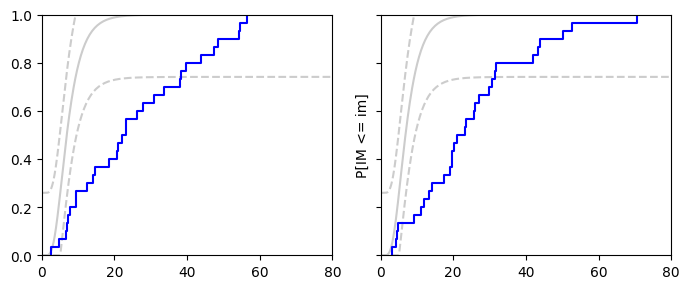

In [217]:
im = "RSD595"
poe1 = 0.000404
poe2 = 0.0001
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

# Figure 1 -> RSD595 KS-Test poe1
records1 = record_selection_results_AvgSA06[poe1]
if records1["ensemble_found"]:
    ensemble1 = records1["best_ensemble"]
    ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])
else:
    rscores = np.array([r["R-score"] for r in records1["all_ensembles"]])
    idx = np.where(rscores == min(rscores))[0][0]
    ensemble1 = records1["all_ensembles"][idx]
    print(f"KS-Test failed for poe {poe1}. Showing ensemble with R = {ensemble1["R-score"]:.4f} and failed IMs {ensemble1["ks_failed_ims"]}")
    ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])

# target cdf and ks bounds
ks_bounds = records1["ks_bounds"][im]
xs = ks_bounds[:, 0]
lower = ks_bounds[:, 1]
cdf = ks_bounds[:, 2]
upper = ks_bounds[:, 3]

# ecdf of records
im_ecdf = ecdfs1[im]

ax1.plot(xs, lower, color="0.8", ls="--")
ax1.plot(xs, cdf, color="0.8", ls="-")
ax1.plot(xs, upper, color="0.8", ls="--")
ax1.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()

# Figure 2 -> RSD595 KS-Test poe2
records2 = record_selection_results_AvgSA06[poe2]
if records2["ensemble_found"]:
    ensemble2 = records2["best_ensemble"]
    ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])
else:
    rscores = np.array([r["R-score"] for r in records2["all_ensembles"]])
    idx = np.where(rscores == min(rscores))[0][0]
    ensemble2 = records2["all_ensembles"][idx]
    print(f"KS-Test failed for poe {poe2}. Showing ensemble with R = {ensemble2["R-score"]:.4f} and failed IMs {ensemble2["ks_failed_ims"]}")
    ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])

# target cdf and ks bounds
ks_bounds = records["ks_bounds"][im]
xs = ks_bounds[:, 0]
lower = ks_bounds[:, 1]
cdf = ks_bounds[:, 2]
upper = ks_bounds[:, 3]

# ecdf of records
im_ecdf = ecdfs2[im]

ax2.plot(xs, lower, color="0.8", ls="--")
ax2.plot(xs, cdf, color="0.8", ls="-")
ax2.plot(xs, upper, color="0.8", ls="--")
ax2.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
ax2.set_xlim(0, 80)
ax2.set_ylim(0, 1.0)
# ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
ax2.set_ylabel(r"P[IM <= im]")
# ax2.grid(True, which="both", ls="-.", color="0.8")
# ax2.minorticks_on()
fig.tight_layout()


In [211]:
ensemble2["recs"]["metadata"]

,index,database,event_id,event_time,station_code,location_code,trt,mag,rjb,vs30,max_usable_T,component,alpha
33676,14267,ESM,IT-1976-0002,1976-05-06 20:00:12,TLM1,0,Shallow Default,6.43,10.220000,458.000000,8.000000,V,4.140094
33411,13954,ESM,GR-1995-0047,1995-06-15 00:15:47,AIGA,0,Shallow Default,6.49,13.610000,524.000000,8.000000,V,2.260306
10320,11484,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,T1201,0,Shallow Default,6.50,6.300000,425.634317,20.000000,U,2.204073
10176,11338,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,CSC,0,Shallow Default,6.50,12.840000,698.000000,20.000000,U,4.079775
31470,11486,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,T1212,0,Shallow Default,6.50,8.770000,537.914756,20.000000,V,2.533876
61902,4028835,NGASub,4000069,YYYY-MM-DD HH:MM:00,4000906,0,Subduction Interface,7.37,156.450732,672.700000,43.936434,H1,38.783847
124126,7004857,NGASub,7000044,YYYY-MM-DD HH:MM:00,7000247,0,Subduction Interface,7.12,109.702909,655.740832,9.181361,H2,10.934273
117570,6001855,NGASub,6000331,YYYY-MM-DD HH:MM:00,6000354,0,Subduction Interface,7.22,157.568627,568.000000,20.954533,H2,12.363196
109244,4033666,NGASub,4000165,YYYY-MM-DD HH:MM:00,4001644,0,Subduction Interface,6.74,200.163429,661.100000,11.924541,H2,179.392535
55068,4018325,NGASub,4000041,YYYY-MM-DD HH:MM:00,4000721,0,Subduction Interface,6.76,174.288217,576.900000,19.715798,H1,117.559061


## GCIM Distributions

In [15]:
LOAD_GCIM_IF_EXISTS = True
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06_rake{int(assumed_rake)}.pickle"

if LOAD_GCIM_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if gcim_dist_fp.is_file():
        with open(gcim_dist_fp, "rb") as file:
            gcim_AvgSA_06 = pickle.load(file)
        print("Existing GCIM distribution data loaded...")
    else:
        no_file = True
        print("No existing GCIM distribution data found...")

if (not LOAD_GCIM_IF_EXISTS) or no_file:
    # calculate the gcims and save them
    gcim_AvgSA_06 = calculate_site_gcim_distributions_for_all_sites(
        disagg_data_AvgSA_06, disagg_stats_AvgSA_06, conditioning_imt, 
        selection_imts, sites, AvgSA_06_gmm_map, AvgSA_06_corr_map, 
        average_depths, assumed_rake, occurence, percentiles)

    with open(gcim_dist_fp, "wb") as file:
        pickle.dump(gcim_AvgSA_06, file)

No existing GCIM distribution data found...
Calculating GCIM Distributions...
  Region 0 - high seismicity
    site id: 30
    site id: 31
    site id: 32
    site id: 33
    site id: 34
  Region 1 - high seismicity
    site id: 35
    site id: 36
    site id: 37
    site id: 38
    site id: 39
  Region 2 - high seismicity
    site id: 40
    site id: 41
    site id: 42
    site id: 43
    site id: 44
  Region 3 - high seismicity
    site id: 45
    site id: 46
    site id: 47
    site id: 48
    site id: 49
  Region 4 - high seismicity
    site id: 50
    site id: 51
    site id: 52
    site id: 53
    site id: 54
  Region 5 - high seismicity
    site id: 55
    site id: 56
    site id: 57
    site id: 58
    site id: 59
  Region 0 - lowmod seismicity
    site id: 0
    site id: 1
    site id: 2
    site id: 3
    site id: 4
  Region 1 - lowmod seismicity
    site id: 5
    site id: 6
    site id: 7
    site id: 8
    site id: 9
  Region 2 - lowmod seismicity
    site id: 10
    site 

## Selection

In [16]:
LOAD_RS_IF_EXISTS = True
AvgSA_06_gm_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_raw_selection_results_rake{int(assumed_rake)}.pickle"

if LOAD_RS_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if AvgSA_06_gm_fp.is_file():
        with open(AvgSA_06_gm_fp, "rb") as file:
            record_selection_results_AvgSA06 = pickle.load(file)
        print("Existing record selection data loaded...")
    else:
        no_file = True
        print("No existing record selection data found...")
        
if (not LOAD_RS_IF_EXISTS) or no_file:
    # do the record selection for all sites and save the results
    record_selection_results_AvgSA06 = get_record_ensembles_for_sites(
        disagg_data_AvgSA_06, disagg_stats_AvgSA_06, gcim_AvgSA_06, 
        gm_db_AvgSA_06, selection_ctx_AvgSA_06, 2    
        )

    # Save the results
    with open(AvgSA_06_gm_fp, "wb") as file:
        pickle.dump(record_selection_results_AvgSA06, file)

No existing record selection data found...
Selecting Record Ensembles...
  Region 0 - high seismicity
    site id: 30
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 31
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 32
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 33
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 34
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 1 - high seismicity
    site id: 35
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id

In [34]:
# Check if all the sites and poes found a set of records successfully
no_ensemble_found_AvgSA06 = []
for (s, r) in record_selection_results_AvgSA06.keys():
    for site_id in record_selection_results_AvgSA06[(s,r)].keys():
        for poe, rsr in record_selection_results_AvgSA06[(s,r)][site_id].items():
            if not rsr["ensemble_found"]:
                no_ensemble_found_AvgSA06.append(((s,r), site_id, poe))

print(f"No records found for {len(no_ensemble_found_AvgSA06)} combinations of site and poe")
for ii in no_ensemble_found_AvgSA06:
    print(ii)

No records found for 207 combinations of site and poe
(('high', 0), 30, np.float64(0.004988))
(('high', 0), 30, np.float64(0.002103))
(('high', 0), 30, np.float64(0.001))
(('high', 0), 30, np.float64(0.000404))
(('high', 0), 30, np.float64(0.000201))
(('high', 0), 30, np.float64(0.0001))
(('high', 0), 31, np.float64(0.000201))
(('high', 0), 31, np.float64(0.0001))
(('high', 0), 32, np.float64(0.002103))
(('high', 0), 32, np.float64(0.001))
(('high', 0), 32, np.float64(0.000404))
(('high', 0), 32, np.float64(0.000201))
(('high', 0), 32, np.float64(0.0001))
(('high', 0), 33, np.float64(0.000404))
(('high', 0), 33, np.float64(0.000201))
(('high', 0), 33, np.float64(0.0001))
(('high', 0), 34, np.float64(0.002103))
(('high', 0), 34, np.float64(0.001))
(('high', 0), 34, np.float64(0.000404))
(('high', 0), 34, np.float64(0.000201))
(('high', 0), 34, np.float64(0.0001))
(('high', 1), 35, np.float64(0.002103))
(('high', 1), 35, np.float64(0.001))
(('high', 1), 35, np.float64(0.000404))
(('high'

# Plotting

In [62]:
gcim_dists

{'stats':                mean       p16       p50        p84
 RSD595     8.184189  4.498559  7.199787  11.632036
 PGA        0.218881  0.118793  0.194183   0.316166
 SA(0.025)  0.239173  0.125836  0.210142   0.349056
 SA(0.032)  0.262920  0.133947  0.228675   0.387628
 SA(0.041)  0.289892  0.142116  0.248990   0.432302
 SA(0.053)  0.329562  0.153843  0.278102   0.498017
 SA(0.068)  0.381417  0.172654  0.318157   0.580835
 SA(0.088)  0.441828  0.198195  0.367031   0.674216
 SA(0.113)  0.495719  0.224273  0.412797   0.754810
 SA(0.146)  0.541802  0.252135  0.455542   0.819104
 SA(0.188)  0.555492  0.272958  0.476170   0.827507
 SA(0.241)  0.530088  0.278466  0.464929   0.774002
 SA(0.311)  0.456047  0.261630  0.411615   0.646018
 SA(0.4)    0.368177  0.227971  0.339822   0.505981
 SA(0.514)  0.292547  0.193452  0.274852   0.390365
 SA(0.662)  0.223758  0.157861  0.213558   0.289044
 SA(0.851)  0.164671  0.121746  0.158787   0.207292
 SA(1.095)  0.119891  0.090860  0.116226   0.148754
 SA

In [48]:
records.keys()

dict_keys(['ensemble_found', 'best_ensemble', 'best_ensemble_idx', 'all_ensembles', 'ks_bounds', 'm_bounds', 'd_bounds', 'vs30_bounds'])

In [ ]:
es = records["all_ensembles"]
e = es[0]
e.keys()
for ei in es:
    print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

dict_keys(['sims', 'mu_cond', 'sig_cond', 'ctxs', 'eps', 'recs', 'ks_passed', 'ks_results', 'ks_failed_ims', 'R-score'])

In [50]:
e["ctxs"]

rec.array([(37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.1,  5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.1,  5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.5,  5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 5.9,  5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.3,  5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.3, 15., 0., 11.716602, 0, 19.033623, 19.033623),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 5.9, 15., 0., 11.716602, 0, 19.033623, 19.033623),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Defau

In [51]:
e["recs"]

metadata                                                       \
         index database               event_id           event_time   
10320    11484      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
31296    11310      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
30447    10453      ESM  EMSC-20161026_0000077  2016-10-26 17:10:36   
33411    13954      ESM           GR-1995-0047  1995-06-15 00:15:47   
42172    22891      ESM           IR-2004-0043  2004-05-28 12:38:43   
37832    18472      ESM           IT-2012-0010  2012-05-29 10:55:56   
34987    15616      ESM           IT-2009-0009  2009-04-06 01:32:40   
14109    15886      ESM           IT-2009-0121  2009-04-09 00:52:59   
18951    20755      ESM           IT-2013-0005  2013-06-21 10:33:56   
19970    21812      ESM           ME-1979-0003  1979-04-15 06:19:41   
30659    10665      ESM  EMSC-20161026_0000095  2016-10-26 19:18:06   
12323    14020      ESM           GR-1999-0001  1999-09-07 11:56:49   
19013    20817      ESM           IT-2013-0005  2013-06-21 10:33:56   
41379    22080      ESM           TK-1999-0389  1999-11-11 14:41:23   
35138    15767      ESM           IT-2009-0102  2009-04-07 17:47:37   
33729    14346      ESM           IT-1976-0027  1976-09-15 03:15:18   
31358    11372      ESM  EMSC-20161030_0000029  2016-10-30 06:40:18   
9299     10453      ESM  EMSC-20161026_0000077  2016-10-26 17:10:36   
41137    21831      ESM           ME-1979-0012  1979-05-24 17:23:17   
28392     8323      ESM  EMSC-20160824_0000006  2016-08-24 01:36:32   
41989    22704      ESM           IR-1994-0020  1994-06-20 09:09:03   
37930    18570      ESM           IT-2012-0011  2012-05-29 07:00:02   
9476     10630      ESM  EMSC-20161026_0000095  2016-10-26 19:18:06   
30753    10759      ESM  EMSC-20161026_0000095  2016-10-26 19:18:06   
7376      8457      ESM  EMSC-20160824_0000006  2016-08-24 01:36:32   
34969    15598      ESM           IT-2009-0009  2009-04-06 01:32:40   
4618      4978      ESM  EMSC-20141122_0000066  2014-11-22 19:14:16   
20848    22710      ESM           IR-1994-0020  1994-06-20 09:09:03   
35182    15811      ESM           IT-2009-0102  2009-04-07 17:47:37   
12315    14012      ESM           GR-1999-0001  1999-09-07 11:56:49   

                                                                             \
      station_code location_code              trt   mag    rjb         vs30   
10320        T1201             0  Shallow Default  6.50   6.30   425.634317   
31296          AMT             0  Shallow Default  6.50  10.12   670.000000   
30447          NRC             0  Shallow Default  5.40  10.10   498.000000   
33411         AIGA             0  Shallow Default  6.49  13.61   524.000000   
42172          ABY             0  Shallow Default  6.34  79.58   453.372276   
37832        MIR06             0  Shallow Default  5.48  18.04   418.430093   
34987          ORC             0  Shallow Default  6.33  33.68   493.239241   
14109          AQP             0  Shallow Default  5.43  11.80   836.000000   
18951         FIVI             0  Shallow Default  5.40  12.10   469.647131   
19970          ULA             0  Shallow Default  6.90   5.56   804.947385   
30659         SPO1             0  Shallow Default  5.90  34.39   533.470351   
12323         RFNA             0  Shallow Default  5.90  31.53   738.726160   
19013          VLM             0  Shallow Default  5.40  37.10   595.287402   
41379         5401             0  Shallow Default  5.67  10.19   412.000000   
35138          AQV             0  Shallow Default  5.54  10.80   474.000000   
33729         SRC0             0  Shallow Default  5.90  12.81   948.153396   
31358          MSC             0  Shallow Default  6.50  22.96   756.133791   
9299           NRC             0  Shallow Default  5.40  10.10   498.000000   
41137          PET             0  Shallow Default  5.90   9.93   776.417843   
28392          BZZ             0  Shallow Default  6.00  37.45   679.00000

In [52]:
e["ks_results"]

{'RSD595': KstestResult(statistic=np.float64(0.1491727967326446), pvalue=np.float64(0.4718259462379064), statistic_location=np.float64(7.065), statistic_sign=np.int8(1)),
 'PGA': KstestResult(statistic=np.float64(0.11705249380589483), pvalue=np.float64(0.7626085950732189), statistic_location=np.float64(0.1075071233521676), statistic_sign=np.int8(1)),
 'SA(0.025)': KstestResult(statistic=np.float64(0.13089356979866998), pvalue=np.float64(0.6356980006045644), statistic_location=np.float64(0.10904703020124785), statistic_sign=np.int8(1))}

In [40]:
for ei in es:
    print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

False, 0.0319, ['SA(5.905)', 'SA(8.0)']
False, 0.0359, ['SA(8.0)']
False, 0.0255, ['SA(5.905)', 'SA(8.0)']
False, 0.0466, ['SA(0.084)', 'SA(1.753)', 'SA(5.905)', 'SA(8.0)']
False, 0.0338, ['SA(0.705)', 'SA(5.905)', 'SA(8.0)']
False, 0.0301, ['SA(4.359)', 'SA(5.905)', 'SA(8.0)']
False, 0.0438, ['SA(0.155)', 'SA(0.384)', 'SA(5.905)', 'SA(8.0)']
False, 0.0306, ['SA(5.905)', 'SA(8.0)']
False, 0.0354, ['SA(0.955)', 'SA(1.753)', 'SA(5.905)', 'SA(8.0)']
False, 0.0351, ['SA(4.359)', 'SA(5.905)', 'SA(8.0)']
False, 0.0383, ['RSD595', 'SA(1.753)', 'SA(8.0)']
False, 0.0444, ['SA(0.384)', 'SA(1.753)', 'SA(4.359)', 'SA(5.905)', 'SA(8.0)']
False, 0.0291, ['SA(5.905)', 'SA(8.0)']
False, 0.0475, ['RSD595', 'SA(0.025)', 'SA(0.034)', 'SA(0.046)', 'SA(0.062)', 'SA(5.905)', 'SA(8.0)']
False, 0.0562, ['PGA', 'SA(0.062)', 'SA(0.084)', 'SA(0.155)', 'SA(0.209)', 'SA(0.384)', 'SA(3.218)', 'SA(4.359)', 'SA(5.905)', 'SA(8.0)']
False, 0.0356, ['SA(0.384)', 'SA(1.294)', 'SA(1.753)', 'SA(5.905)', 'SA(8.0)']
False, 0

In [18]:
# ('high', 0), 30, np.float64(0.019801))

In [19]:
# ensemble_data = records["best_ensemble"]
# ecdfs = ensemble_ecdfs(ensemble_data["recs"]["ims_scaled"])
# ensemble_data["ecdfs"] = ecdfs
# print(ensemble_data.keys())
# print(ecdfs.keys())

In [20]:
# gcim_data = gcim_AvgSA_03[("high", 0)][31][0.000201]
# gcim_data["stats"]

In [21]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# import matplotlib.lines as mlines

# from phd_project.plotting import custom_log_formatter

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# trt_format = {
#     "Shallow Default": {"color":"b", "alpha": 0.8, "lw":1} ,
#     "Subduction Interface": {"color":"r", "alpha": 0.5, "lw":1} ,
#     "Subduction Inslab": {"color":"g", "alpha": 0.8, "lw":1} ,
# }

# periods = [0.01] + [im.period for im in selection_imts if im.name == "SA"]
# sas = ["PGA"] + [im.string for im in selection_imts if im.name == "SA"]
# sa_dists = gcim_data["stats"].loc[sas, :]
# recs = ensemble_data["recs"]

# # Figure 1 Conditional Spectra
# for ii, (_, row) in enumerate(recs["ims_scaled"].iterrows()):
#     trt = ensemble_data["ctxs"][ii].trt
#     sa_rec = row[sas]
#     if trt != "Shallow Default":
#         alpha = 0.6
#     else:
#         alpha = 1.0
#     ax1.loglog(periods, sa_rec, **trt_format[trt])

# ax1.loglog(periods, sa_dists["p5"], color="k", ls="--")
# ax1.loglog(periods, sa_dists["p16"], color="k", ls="-.")
# ax1.loglog(periods, sa_dists["p50"], color="k")
# ax1.loglog(periods, sa_dists["p84"], color="k", ls="-.")
# ax1.loglog(periods, sa_dists["p95"], color="k", ls="--")

# formatter = ticker.FuncFormatter(custom_log_formatter)
# ax1.xaxis.set_major_formatter(formatter)
# ax1.set_xlim(0.01, 8)
# ax1.set_ylim(1e-2, 5)

# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()
# ax1.tick_params(axis='y', which='minor', left=False)
# ax1.set_xlabel("Period, [s]")
# ax1.set_ylabel("SA [g]")

# # Figure 2 -> RSD595 KS-Test
# im = "RSD595"
# # target cdf and ks bounds
# ks_bounds = records["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs[im]

# ax2.plot(xs, lower, color="0.8", ls="--")
# ax2.plot(xs, cdf, color="0.8", ls="-")
# ax2.plot(xs, upper, color="0.8", ls="--")
# ax2.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# ax2.set_xlim(0, 120)
# ax2.set_ylim(0, 1.0)
# ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
# ax2.set_ylabel(r"P[IM <= im]")
# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()
# fig.tight_layout()


In [23]:
# # The trt stats
# trt_stats = pd.DataFrame(recs.groupby(("metadata", "trt")).size())
# trt_stats.columns = ["count"]
# trt_stats["proportions"] = np.round(trt_stats["count"] / trt_stats["count"].sum(), 3)
# trt_stats

In [24]:
# # Table of KS results
# data = {im : {"ks_statistic": ksr.statistic * ksr.statistic_sign, 
#               "pvalue": ksr.pvalue, 
#               "location": ksr.statistic_location} 
#         for im , ksr in ensemble_data["ks_results"].items()}

# ks_data = pd.DataFrame.from_dict(data, orient="index")
# ks_data

In [25]:
# # Record data
# metadata = recs["metadata"]
# record_data_for_table = metadata[["event_id", "database", "station_code", "trt", "mag", "rjb", "vs30", "component"]]
# record_data_for_table

In [168]:
fp = Path(r"C:\Users\clemettn\Documents\phd\data_processed\06_gm_selection")
site = 30
rakes = [0, 90, -90]

site_records = {}
site_records_sflim = {}

for rake in rakes:
    with open(fp / f"site{site}_record_selections_rake{rake}.pickle", "rb") as file:
        site_records[rake] = pickle.load(file)

    with open(fp / f"site{site}_record_selections_rake{rake}_sf_limit.pickle", "rb") as file:
        site_records_sflim[rake] = pickle.load(file)

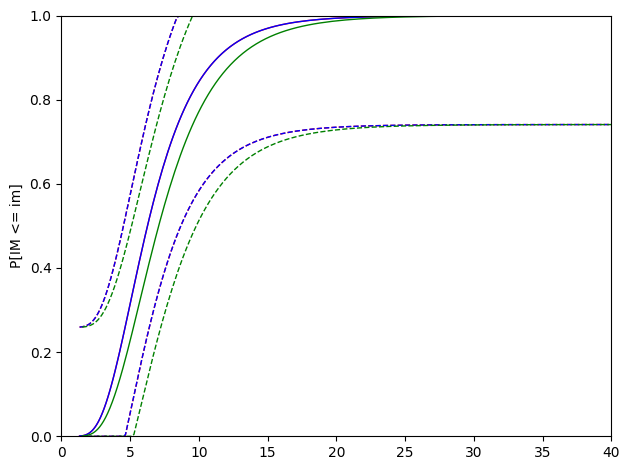

In [169]:
im = "RSD595"
poe = 0.0001
fig, ax = plt.subplots()

for rake, c in zip(rakes, ["r", "b", "g"]):
    rs = site_records[rake][poe]
    ensemble = rs["best_ensemble"]
    ecdfs = ensemble_ecdfs(ensemble["recs"]["ims_scaled"])

    # target cdf and ks bounds
    ks_bounds = rs["ks_bounds"][im]
    xs = ks_bounds[:, 0]
    lower = ks_bounds[:, 1]
    cdf = ks_bounds[:, 2]
    upper = ks_bounds[:, 3]

    # ecdf of records
    im_ecdf = ecdfs1[im]

    ax.plot(xs, lower, ls="--", color=c, lw=1.0)
    ax.plot(xs, cdf, ls="-", color=c, lw=1.0)
    ax.plot(xs, upper, ls="--", color=c, lw=1.0)
    # ax.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
    # ax1.grid(True, which="both", ls="-.", color="0.8")
    # ax1.minorticks_on()

    ax.set_xlim(0, 40)
    ax.set_ylim(0, 1.0)
    # ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
    ax.set_ylabel(r"P[IM <= im]")
    # ax2.grid(True, which="both", ls="-.", color="0.8")
    # ax2.minorticks_on()
    fig.tight_layout()


In [179]:
site_records[0][0.0001]["best_ensemble"]["ctxs"]

rec.array([(37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.9, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.3, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.5, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.5, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.3, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 5.9, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.7, 5., 0., 11.716602, 0, 12.738869, 12.738869),
           (37.7, -1.71787, 0, 800,  True, 150., 31.07, 0.57, 'Shallow Default', 6.

In [178]:
site_records[0][0.0001]["best_ensemble"]["recs"]["metadata"]

,index,database,event_id,event_time,station_code,location_code,trt,mag,rjb,vs30,max_usable_T,component,alpha
33742,14359,ESM,IT-1976-0030,1976-09-15 09:21:18,SRC0,0,Shallow Default,5.95,10.90,948.153396,8.000000,V,5.804146
12315,14012,ESM,GR-1999-0001,1999-09-07 11:56:49,ATH4,0,Shallow Default,5.90,14.04,1020.000000,4.000000,U,7.729649
33729,14346,ESM,IT-1976-0027,1976-09-15 03:15:18,SRC0,0,Shallow Default,5.90,12.81,948.153396,5.333333,V,11.936029
12625,14393,ESM,IT-1978-0004,1978-04-15 23:33:47,PTT1,0,Shallow Default,6.03,12.11,480.923495,4.000000,U,5.762081
31390,11406,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,SPD,0,Shallow Default,6.50,24.89,968.233606,10.000000,V,6.920740
9442,10596,ESM,EMSC-20161026_0000095,2016-10-26 19:18:06,CLO,0,Shallow Default,5.90,3.15,420.485640,11.428571,U,7.234666
7289,8368,ESM,EMSC-20160824_0000006,2016-08-24 01:36:32,MSC,0,Shallow Default,6.00,14.27,756.133791,16.000000,U,7.483815
12143,13815,ESM,GR-1990-0014,1990-12-21 06:57:43,ABS1,0,Shallow Default,6.09,78.10,760.278638,4.000000,U,49.004313
10323,11487,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,T1213,0,Shallow Default,6.50,4.41,588.001562,20.000000,U,1.527924
31468,11484,ESM,EMSC-20161030_0000029,2016-10-30 06:40:18,T1201,0,Shallow Default,6.50,6.30,425.634317,20.000000,V,1.355218


In [177]:
poe = 0.0001
print(site_records_sflim[0][poe]["ensemble_found"])
print(site_records_sflim[90][poe]["ensemble_found"])
print(site_records_sflim[-90][poe]["ensemble_found"])

False
False
False
